In [ ]:
import os
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

runs_dir = os.path.normpath(os.path.join(os.getcwd(), "..", "..", "runs"))
ea = EventAccumulator(runs_dir)
ea.Reload()

# Get P1_stuck values — stuck=0 means finished
p1_stuck = ea.Scalars("episode/P1_stuck")
p2_stuck = ea.Scalars("episode/P2_stuck")

p1_finishes = sum(1 for s in p1_stuck if s.value == 0)
p2_finishes = sum(1 for s in p2_stuck if s.value == 0)

print(f"P1 finishes: {p1_finishes}")
print(f"P2 finishes: {p2_finishes}")
print(f"Total episodes with at least one finish: {sum(1 for p1, p2 in zip(p1_stuck, p2_stuck) if p1.value == 0 or p2.value == 0)}")

In [2]:
p1_rewards = ea.Scalars("episode/P1_reward")
best_p1 = max(p1_rewards, key=lambda s: s.value)
print(f"Best P1 episode: {best_p1.step} with reward {best_p1.value:.2f}")

Best P1 episode: 847 with reward 249.43


In [3]:
last_100 = [s.value for s in p1_rewards[-100:]]
print(f"P1 average reward last 100 episodes: {sum(last_100)/len(last_100):.2f}")

P1 average reward last 100 episodes: 2.28


In [4]:
action_totals = {}
for tag in ea.Tags()["scalars"]:
    if tag.startswith("actions/P1_"):
        name = tag.replace("actions/P1_", "")
        total = sum(s.value for s in ea.Scalars(tag))
        action_totals[name] = total

for action, count in sorted(action_totals.items(), key=lambda x: -x[1]):
    print(f"{action}: {int(count)}")

accel_right: 4554706
drift_hard_left: 2144489
wheelie_left: 436987
drift_hard_right: 91373
drift_soft_right: 36500
nothing: 33505
drift_soft_left: 30000
brake_right: 18023
accel_center: 17506
brake_center: 10968
brake_left: 10326
wheelie_center: 9541
accel_left: 8101
drift_center: 4389
wheelie_right: 3602


In [5]:
import numpy as np
stuck_values = [s.value for s in p1_stuck]
window = 500
rolling = [1 - np.mean(stuck_values[i:i+window]) for i in range(len(stuck_values)-window)]
print(f"Finish rate first 500 episodes: {rolling[0]:.1%}")
print(f"Finish rate last 500 episodes: {rolling[-1]:.1%}")

Finish rate first 500 episodes: 0.0%
Finish rate last 500 episodes: 30.2%


In [ ]:
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator
from datetime import timedelta
import numpy as np

ea = EventAccumulator(runs_dir)
ea.Reload()

scalars = ea.Scalars("train/loss")
p1_stuck = ea.Scalars("episode/P1_stuck")
p1_progress = ea.Scalars("episode/P1_progress")

# Training time
times = [s.wall_time for s in scalars]
gaps = np.diff(times)
BREAK_THRESHOLD = 300
compute_gaps = gaps[gaps < BREAK_THRESHOLD]
compute_time = timedelta(seconds=float(compute_gaps.sum()))
print(f"Estimated compute time: {compute_time}")
#amount of episodes
total_episodes = len(p1_stuck)
print(f"Total episodes: {total_episodes}")
#aomount of breaks and average break time
breaks = gaps[gaps >= BREAK_THRESHOLD]
print(f"Number of breaks: {len(breaks)}")

In [9]:
# Save state analysis
finished_episodes = [(s.step, p.value) for s, p in zip(p1_stuck, p1_progress) if s.value == 0]
early_start = [(ep, prog) for ep, prog in finished_episodes if prog > 2.5]
mid_start = [(ep, prog) for ep, prog in finished_episodes if 1.5 < prog <= 2.5]
late_start = [(ep, prog) for ep, prog in finished_episodes if prog <= 1.5]
print(f"Started near beginning (progress >2.5): {len(early_start)}")
print(f"Started mid-track (1.5-2.5): {len(mid_start)}")
print(f"Started late (progress <1.5): {len(late_start)}")

Started near beginning (progress >2.5): 739
Started mid-track (1.5-2.5): 923
Started late (progress <1.5): 0


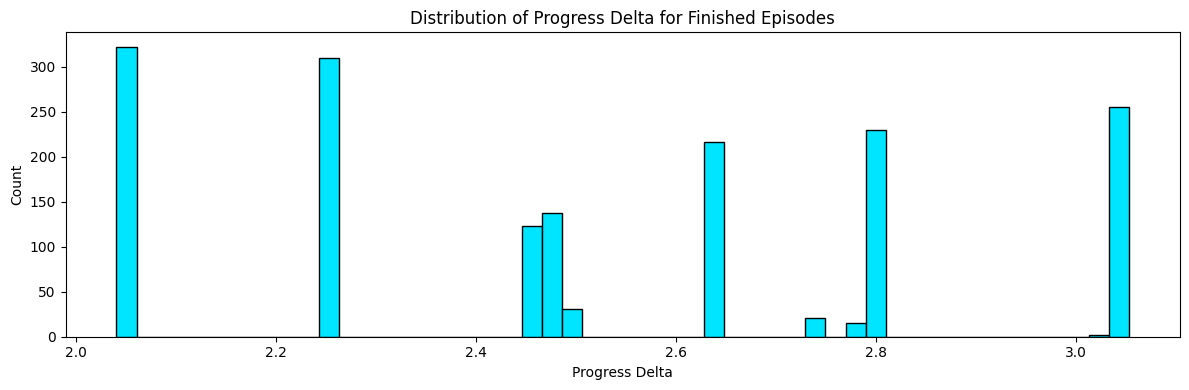

Progress ~2.0: 32 episodes
Progress ~2.1: 290 episodes
Progress ~2.2: 37 episodes
Progress ~2.3: 273 episodes
Progress ~2.5: 291 episodes
Progress ~2.6: 216 episodes
Progress ~2.7: 21 episodes
Progress ~2.8: 245 episodes
Progress ~3.0: 20 episodes
Progress ~3.1: 237 episodes


In [12]:
import matplotlib.pyplot as plt

finished_progress = [prog for _, prog in finished_episodes]

plt.figure(figsize=(12, 4))
plt.hist(finished_progress, bins=50, color='#00E5FF', edgecolor='black')
plt.xlabel('Progress Delta')
plt.ylabel('Count')
plt.title('Distribution of Progress Delta for Finished Episodes')
plt.tight_layout()
plt.show()

# Also print the distinct clusters
import numpy as np
rounded = [round(p, 1) for p in finished_progress]
from collections import Counter
for val, count in sorted(Counter(rounded).items()):
    print(f"Progress ~{val}: {count} episodes")

In [13]:
p1_rewards = ea.Scalars("episode/P1_reward")

# Match rewards to progress clusters for finished episodes
def get_cluster(progress):
    if progress < 2.2:
        return "~2.1 (latest start)"
    elif progress < 2.4:
        return "~2.3"
    elif progress < 2.55:
        return "~2.5"
    elif progress < 2.7:
        return "~2.6"
    elif progress < 2.9:
        return "~2.8"
    else:
        return "~3.1 (earliest start)"

# Build step->reward lookup
reward_by_step = {s.step: s.value for s in p1_rewards}

# Cross reference
from collections import defaultdict
cluster_rewards = defaultdict(list)

for step, prog in finished_episodes:
    if step in reward_by_step:
        cluster = get_cluster(prog)
        cluster_rewards[cluster].append(reward_by_step[step])

for cluster, rewards in sorted(cluster_rewards.items()):
    print(f"{cluster}: avg={sum(rewards)/len(rewards):.1f} min={min(rewards):.1f} max={max(rewards):.1f} n={len(rewards)}")
    

~2.1 (latest start): avg=92.0 min=-35.3 max=194.1 n=322
~2.3: avg=98.2 min=19.6 max=163.2 n=310
~2.5: avg=104.8 min=36.3 max=181.7 n=291
~2.6: avg=107.6 min=29.7 max=208.4 n=216
~2.8: avg=94.6 min=16.8 max=249.4 n=266
~3.1 (earliest start): avg=109.9 min=8.7 max=217.0 n=257
